# Sachs

In [3]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import lightning as L
import torch
import os, sys
import numpy as np
import pickle
sys.path.append("/home/taehui/causally-reliable-cbm/")
from src.data.datasets.bndataset import BNDataset
import networkx as nx
from utils import *
torch.manual_seed(0)
np.random.seed(0)



In [4]:
task_name = "dysp"
BND = BNDataset(dag_name = 'asia', task_name = "dysp",
                dataset_n_samples = 10000,
                test_size = 0.2,
                val_size = 0.1)

BND.split()
train = BND.data['train']
val = BND.data['val']
test = BND.data['test']



[18-12-2025 17:39:22] [datazets.datazets] [INFO] Extracting files..


[bnlearn] >Import <asia>
[bnlearn] >Loading bif file </opt/anaconda3/envs/tei_just/lib/python3.11/site-packages/datazets/data/asia.bif>
[bnlearn] >[CPD > Validate] >[Node asia] >OK
[bnlearn] >[CPD > Validate] >[Node bronc] >OK
[bnlearn] >[CPD > Validate] >[Node dysp] >OK
[bnlearn] >[CPD > Validate] >[Node either] >OK
[bnlearn] >[CPD > Validate] >[Node lung] >OK
[bnlearn] >[CPD > Validate] >[Node smoke] >OK
[bnlearn] >[CPD > Validate] >[Node tub] >OK
[bnlearn] >[CPD > Validate] >[Node xray] >OK


  0%|          | 0/8 [00:00<?, ?it/s]

  0%|          | 0/8 [00:00<?, ?it/s]

  0%|          | 0/8 [00:00<?, ?it/s]

## gragh check

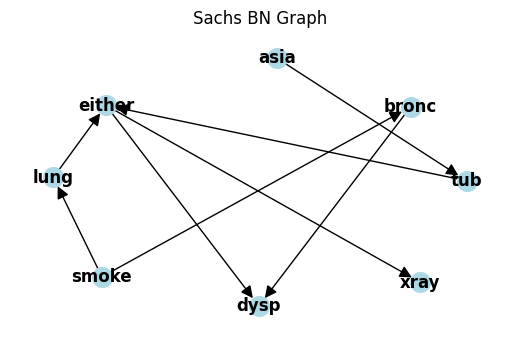

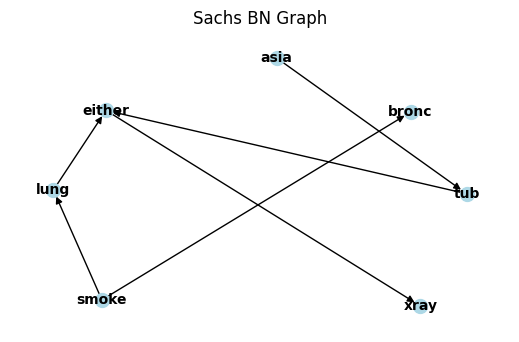

In [5]:
adj_pd = BND.load_ground_truth_graph()
adj_org = nx.from_pandas_adjacency(adj_pd, create_using=nx.DiGraph)
plt.figure(figsize=(5, 3))
# Use spring_layout for more spread out nodes (can adjust k for more spread)
pos = nx.spring_layout(adj_org, k=3, seed=42)  # Increase k for more spread
nx.draw(adj_org, pos=pos, with_labels=True, node_color='lightblue', node_size=200, font_size=12, font_weight='bold', arrowsize=18)
plt.title('Sachs BN Graph')
plt.tight_layout()
plt.show()

#remove task_name from adj_pd ; column and row
adj_pd = adj_pd.drop(task_name, axis=0).drop(task_name, axis=1)

graph_sachs = nx.from_pandas_adjacency(adj_pd, create_using=nx.DiGraph)

# Plot the graph
plt.figure(figsize=(5, 3))
nx.draw(graph_sachs,pos = pos, with_labels=True, node_color='lightblue', node_size=100, font_size=10, font_weight='bold')
plt.title('Sachs BN Graph')
plt.show()

In [6]:

order = adj_pd.index.tolist()
topo_order = list(nx.topological_sort(graph_sachs))
print("Topological order of nodes:", topo_order)
print("Before topological order:", order)

topo_order_idx = [order.index(node) for node in topo_order]

# rearrange adj_pd with topo_order
adj_pd_topo = adj_pd.loc[topo_order, topo_order]
print(adj_pd_topo)
print(adj_pd)

adj_cnf = adj_pd_topo.to_numpy(dtype=np.int8).transpose(1,0)
adj_cnf += np.eye(adj_cnf.shape[0], dtype=np.int8)
adj_cnf



Topological order of nodes: ['asia', 'smoke', 'tub', 'lung', 'bronc', 'either', 'xray']
Before topological order: ['asia', 'tub', 'smoke', 'lung', 'bronc', 'either', 'xray']
target  asia  smoke  tub  lung  bronc  either  xray
source                                             
asia       0      0    1     0      0       0     0
smoke      0      0    0     1      1       0     0
tub        0      0    0     0      0       1     0
lung       0      0    0     0      0       1     0
bronc      0      0    0     0      0       0     0
either     0      0    0     0      0       0     1
xray       0      0    0     0      0       0     0
target  asia  tub  smoke  lung  bronc  either  xray
source                                             
asia       0    1      0     0      0       0     0
tub        0    0      0     0      0       1     0
smoke      0    0      0     1      1       0     0
lung       0    0      0     0      0       1     0
bronc      0    0      0     0      0       0 

array([[1, 0, 0, 0, 0, 0, 0],
       [0, 1, 0, 0, 0, 0, 0],
       [1, 0, 1, 0, 0, 0, 0],
       [0, 1, 0, 1, 0, 0, 0],
       [0, 1, 0, 0, 1, 0, 0],
       [0, 0, 1, 1, 0, 1, 0],
       [0, 0, 0, 0, 0, 1, 1]], dtype=int8)

## CNF Learning and Inference on Sachs dataset

### Data check

In [7]:

def post_process(x, binary_dims, binary_min_values, binary_max_values, inplace=False):
    if not inplace:
        x = x.clone()
    x[..., binary_dims] = x[..., binary_dims].floor().float()
    x[..., binary_dims] = torch.clamp(x[..., binary_dims], min=binary_min_values, max=binary_max_values)

    return x

def add_noise(x):
    # Calculate the standard deviation of each column
    std = torch.std(x, dim=0).mul(100).round() / 100.0

    # Find the columns that are constant (i.e., have a standard deviation of 0)
    constant_mask = std == 0
    # # Generate a small amount of noise for each constant column
    # noise = torch.rand(x.shape[0], sum(constant_mask)) * 2.0 - 1.0
    noise = torch.randn(x.shape[0], sum(constant_mask))
    # Add the noise to the corresponding columns
    x[:, constant_mask] += noise * 0.01
    return x

In [9]:
# dataset as tensor
train_C = torch.tensor(train.c)
train_Y = torch.tensor(train.y)
print(train_C.shape, train_Y.shape)

test_C = torch.tensor(test.c)
test_Y = torch.tensor(test.y)
print(test_C.shape, test_Y.shape)

val_C = torch.tensor(val.c)
val_Y = torch.tensor(val.y)
val_C.shape, val_Y.shape


##preprocessing

#column-wise rearrange as topological order (topo_order_idx)
train_C_topo = train_C[:,topo_order_idx]
test_C_topo = test_C[:,topo_order_idx]
val_C_topo = val_C[:,topo_order_idx]

train_C_topo.shape, test_C_topo.shape, val_C_topo.shape


# binary idx
binary_dims = list(range(0, train_C.shape[1]))
binary_min_values = train_C[:, binary_dims].min(dim=0)[0]
binary_max_values = train_C[:, binary_dims].max(dim=0)[0]

#dequantization
train_C_topo_deq = train_C_topo[:, binary_dims] + torch.rand_like(train_C_topo[:, binary_dims])
test_C_topo_deq = test_C_topo[:, binary_dims] + torch.rand_like(test_C_topo[:, binary_dims])
val_C_topo_deq = val_C_topo[:, binary_dims] + torch.rand_like(val_C_topo[:, binary_dims])
print(train_C_topo_deq.shape, test_C_topo_deq.shape, val_C_topo_deq.shape)

def create_df(tensors_dict):
    df_list = []
    for i, (k, x) in enumerate(tensors_dict.items()):
        df = pd.DataFrame(x.numpy(), columns=[f'$x_{j}$' for j in range(x.shape[1])])
        df['name'] = k
        df_list.append(df)

    df = pd.concat(df_list)
    return df


def plot_data(tensors_dict, mode = "kde"):
    df = create_df(tensors_dict)
    g = sns.PairGrid(df, diag_sharey=False, hue='name')
    g.map_upper(sns.scatterplot, s=15, alpha=0.5)
    if mode == "kde":
        g.map_lower(sns.kdeplot, common_norm=False)
        g.map_diag(sns.kdeplot, lw=2, common_norm=False)
    elif mode == "hist":
        g.map_lower(sns.histplot, bins=20)
        g.map_diag(sns.histplot, bins=20)
    g.add_legend()
    plt.show()



# plot_data({'Data': test_C_topo_deq}, "kde")

torch.Size([7000, 7]) torch.Size([7000, 1])
torch.Size([2000, 7]) torch.Size([2000, 1])
torch.Size([7000, 7]) torch.Size([2000, 7]) torch.Size([1000, 7])


### Training

In [10]:

from torch.utils.data import DataLoader, TensorDataset
# Create the dataloaders
batch_size = 100
train_dataset = TensorDataset(train_C_topo_deq)
train_loader = DataLoader(train_dataset, batch_size, shuffle=True)

test_dataset = TensorDataset(test_C_topo_deq)
test_loader = DataLoader(test_dataset, batch_size=test_C_topo_deq.shape[0])

In [11]:
from causalflows.flows import CausalMAF

features = 7
context = 0
flow = CausalMAF(features, context, adjacency=adj_cnf)




# init the autoencoder
model = LitFlow(flow)

logger = MyLogger()
trainer = L.Trainer(
    max_epochs=200, logger=logger, enable_checkpointing=False, log_every_n_steps=len(train_loader)
)
trainer.fit(model=model, train_dataloaders=train_loader)

Trainer will use only 1 of 6 GPUs because it is running inside an interactive / notebook environment. You may try to set `Trainer(devices=6)` but please note that multi-GPU inside interactive / notebook environments is considered experimental and unstable. Your mileage may vary.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
You are using a CUDA device ('NVIDIA RTX 6000 Ada Generation') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1,2,3,4,5]

  | Name | Type      | Params | Mode  | FLOPs
---------------------------------------------------
0 | flow | CausalMAF | 5.6 K  | train | 0    
---------------------------------------------------
5.6 K     Trainable 

Training: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=200` reached.


save model

In [12]:
save_file = "cnf_bundle_asia.pt"
torch.save({
    "state_dict": model.flow.state_dict(),
    "features": features,
    "context": context,
    "adjacency": adj_cnf,
    "topo_order_idx": topo_order_idx,
    "original_order": order,
    "topological_order": topo_order,
    "binary_dims": binary_dims,
    "binary_min_values": binary_min_values,
    "binary_max_values": binary_max_values,
}, save_file)

load model (optional)

In [13]:
save_file = "cnf_bundle_asia.pt"
bundle = torch.load(save_file, map_location="cpu")
flow_loaded = CausalMAF(bundle["features"], bundle["context"], adjacency=bundle["adjacency"])
flow_loaded.load_state_dict(bundle["state_dict"])
flow_loaded.eval()

CausalMAF(
  (transform): MaskedAutoregressiveTransform(
    (base): MonotonicAffineTransform()
    (passes): 4
    (hyper): MaskedMLP(
      (0): MaskedLinear(in_features=7, out_features=64, bias=True)
      (1): ReLU()
      (2): MaskedLinear(in_features=64, out_features=64, bias=True)
      (3): ReLU()
      (4): MaskedLinear(in_features=64, out_features=14, bias=True)
    )
  )
  (base): UnconditionalDistribution(DiagNormal(loc: torch.Size([7]), scale: torch.Size([7])))
)

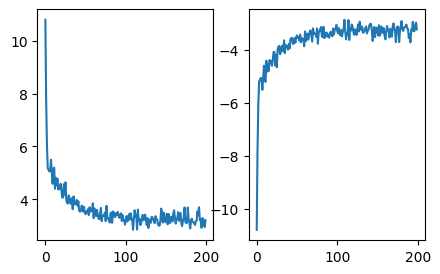

In [14]:
fig, axs = plt.subplots(1, 2, figsize=(5, 3))
sns.lineplot(x=logger.values['epoch'], y=logger.values['train_loss'], ax=axs[0])
sns.lineplot(x=logger.values['epoch'], y=logger.values['log_prob'], ax=axs[1])
plt.show()

### Inference

observational

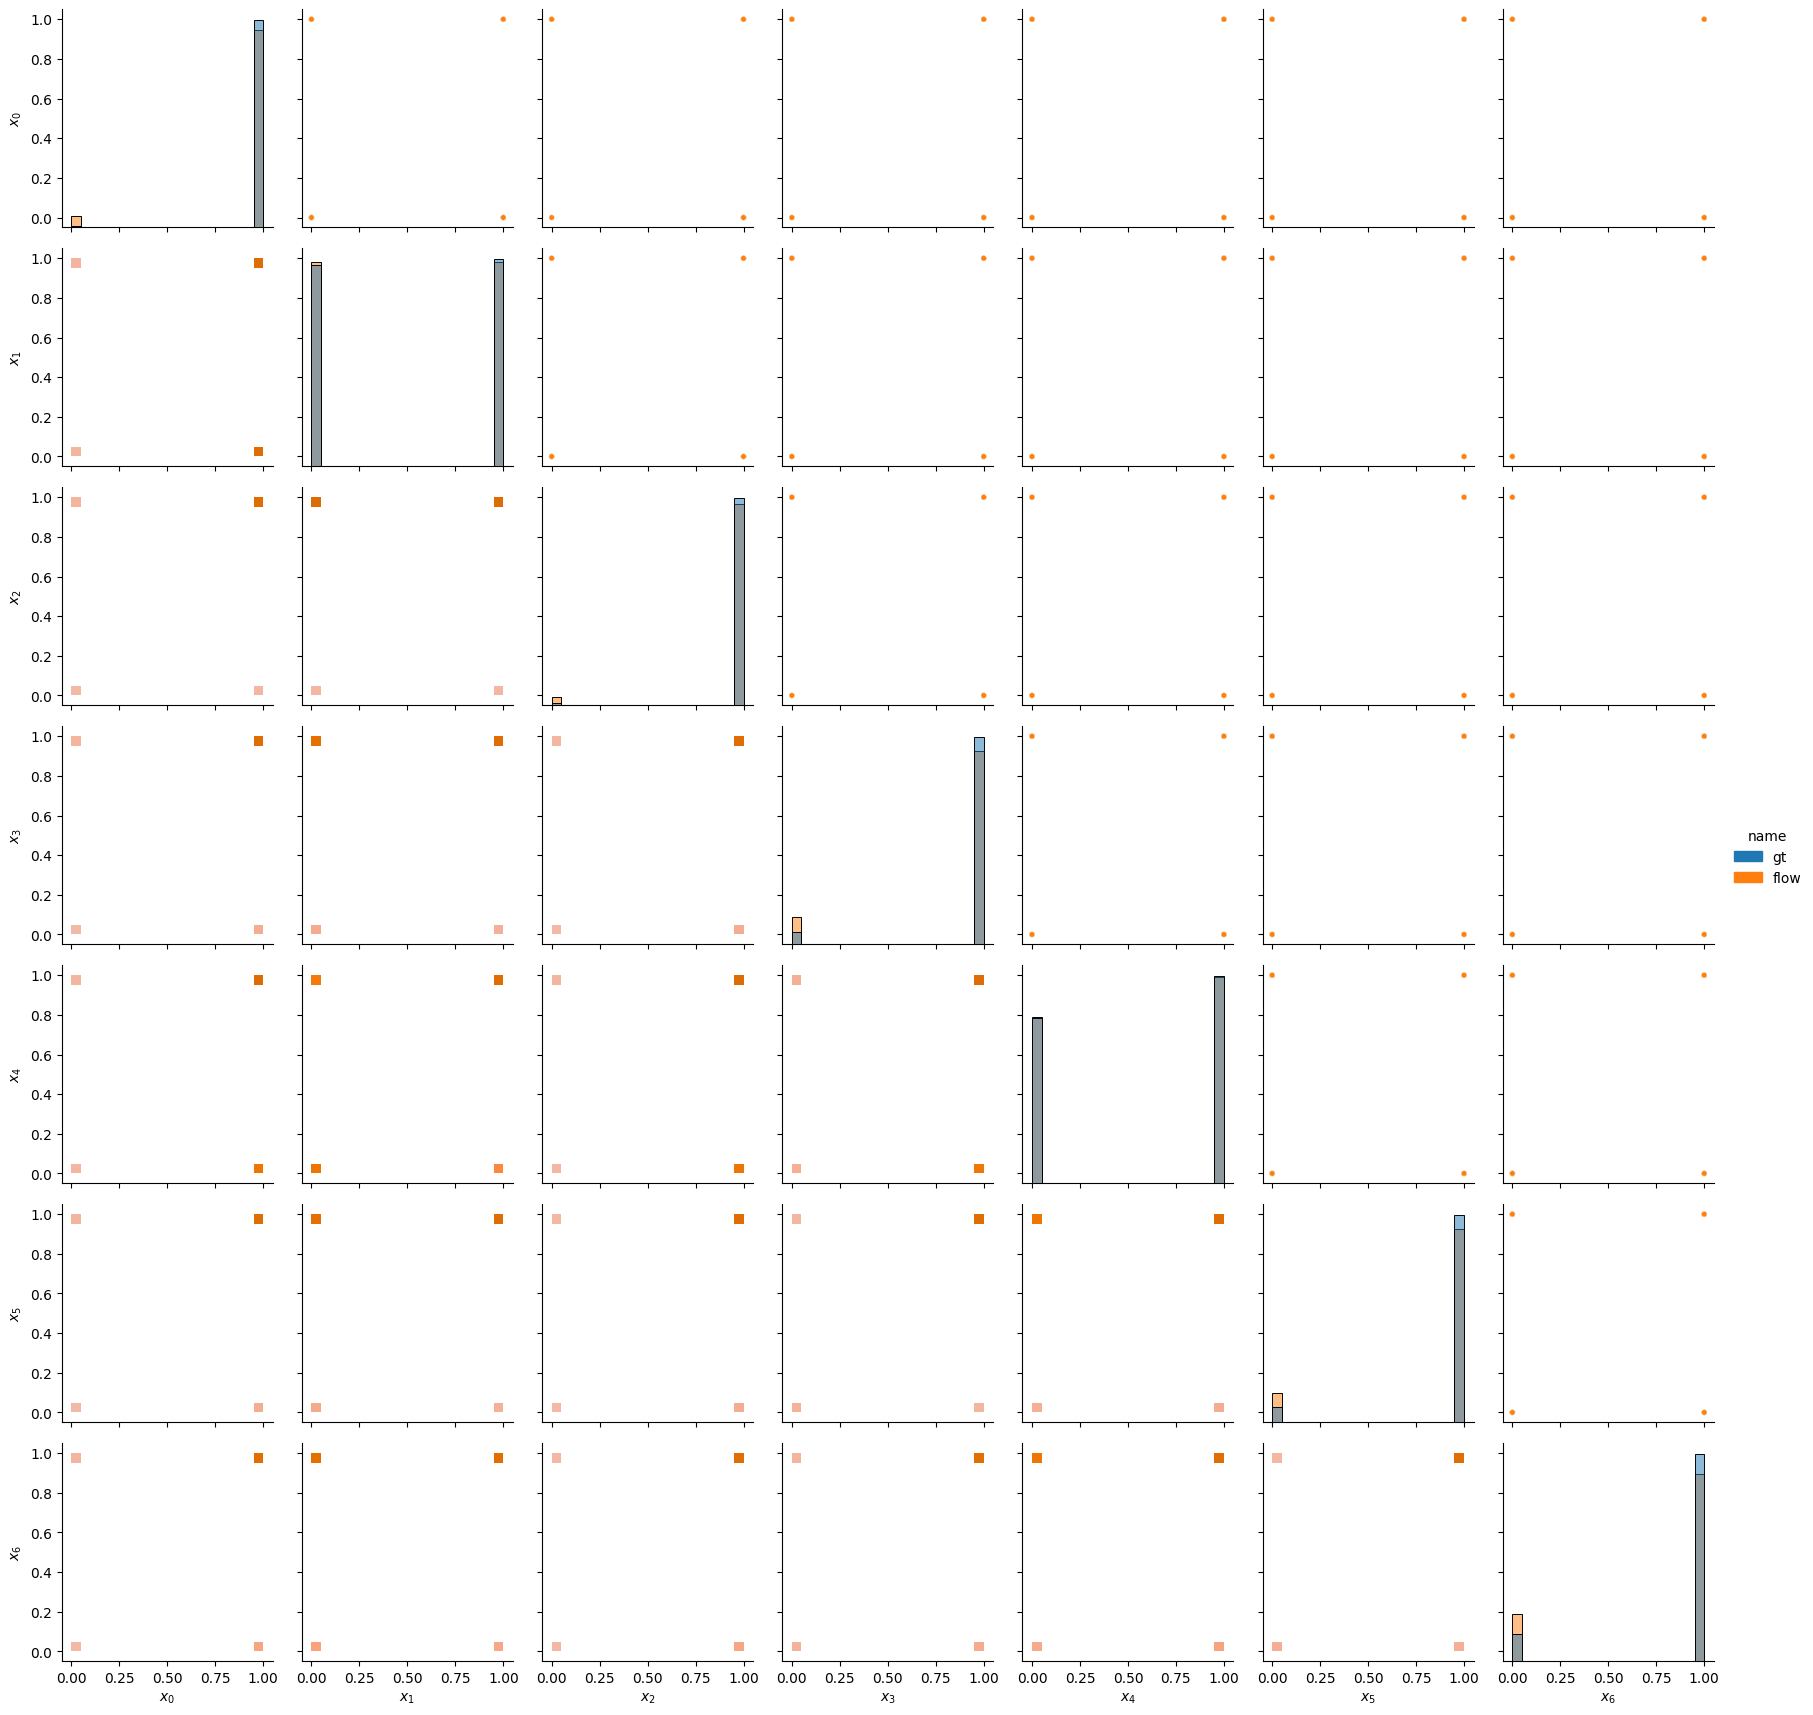

In [15]:
# observational
gt_obs = post_process(test_C_topo_deq, binary_dims, binary_min_values, binary_max_values)
obs_data =flow().sample([test_C_topo_deq.shape[0]])
obs_data = post_process(obs_data, binary_dims, binary_min_values, binary_max_values)

plot_data({'gt': gt_obs, 'flow': obs_data}, "hist")


interventional

In [ ]:
# intervention
index, value = 0, 0

#"simple" ground truth : conditional on root is same as intervention on root
mask = test_C_topo_deq[..., index].floor() == int(value)
int_gt = test_C_topo_deq[mask, :]
int_gt = add_noise(post_process(int_gt, binary_dims, binary_min_values, binary_max_values))

#generate intervention data
int_data = flow().sample_interventional(index=0, value=0+torch.rand(1), sample_shape=(int_gt.shape[0],))
int_data = add_noise(post_process(int_data, binary_dims, binary_min_values, binary_max_values))

#plot
plot_data({'gt': int_gt, 'flow': int_data}, "hist")


counterfactual

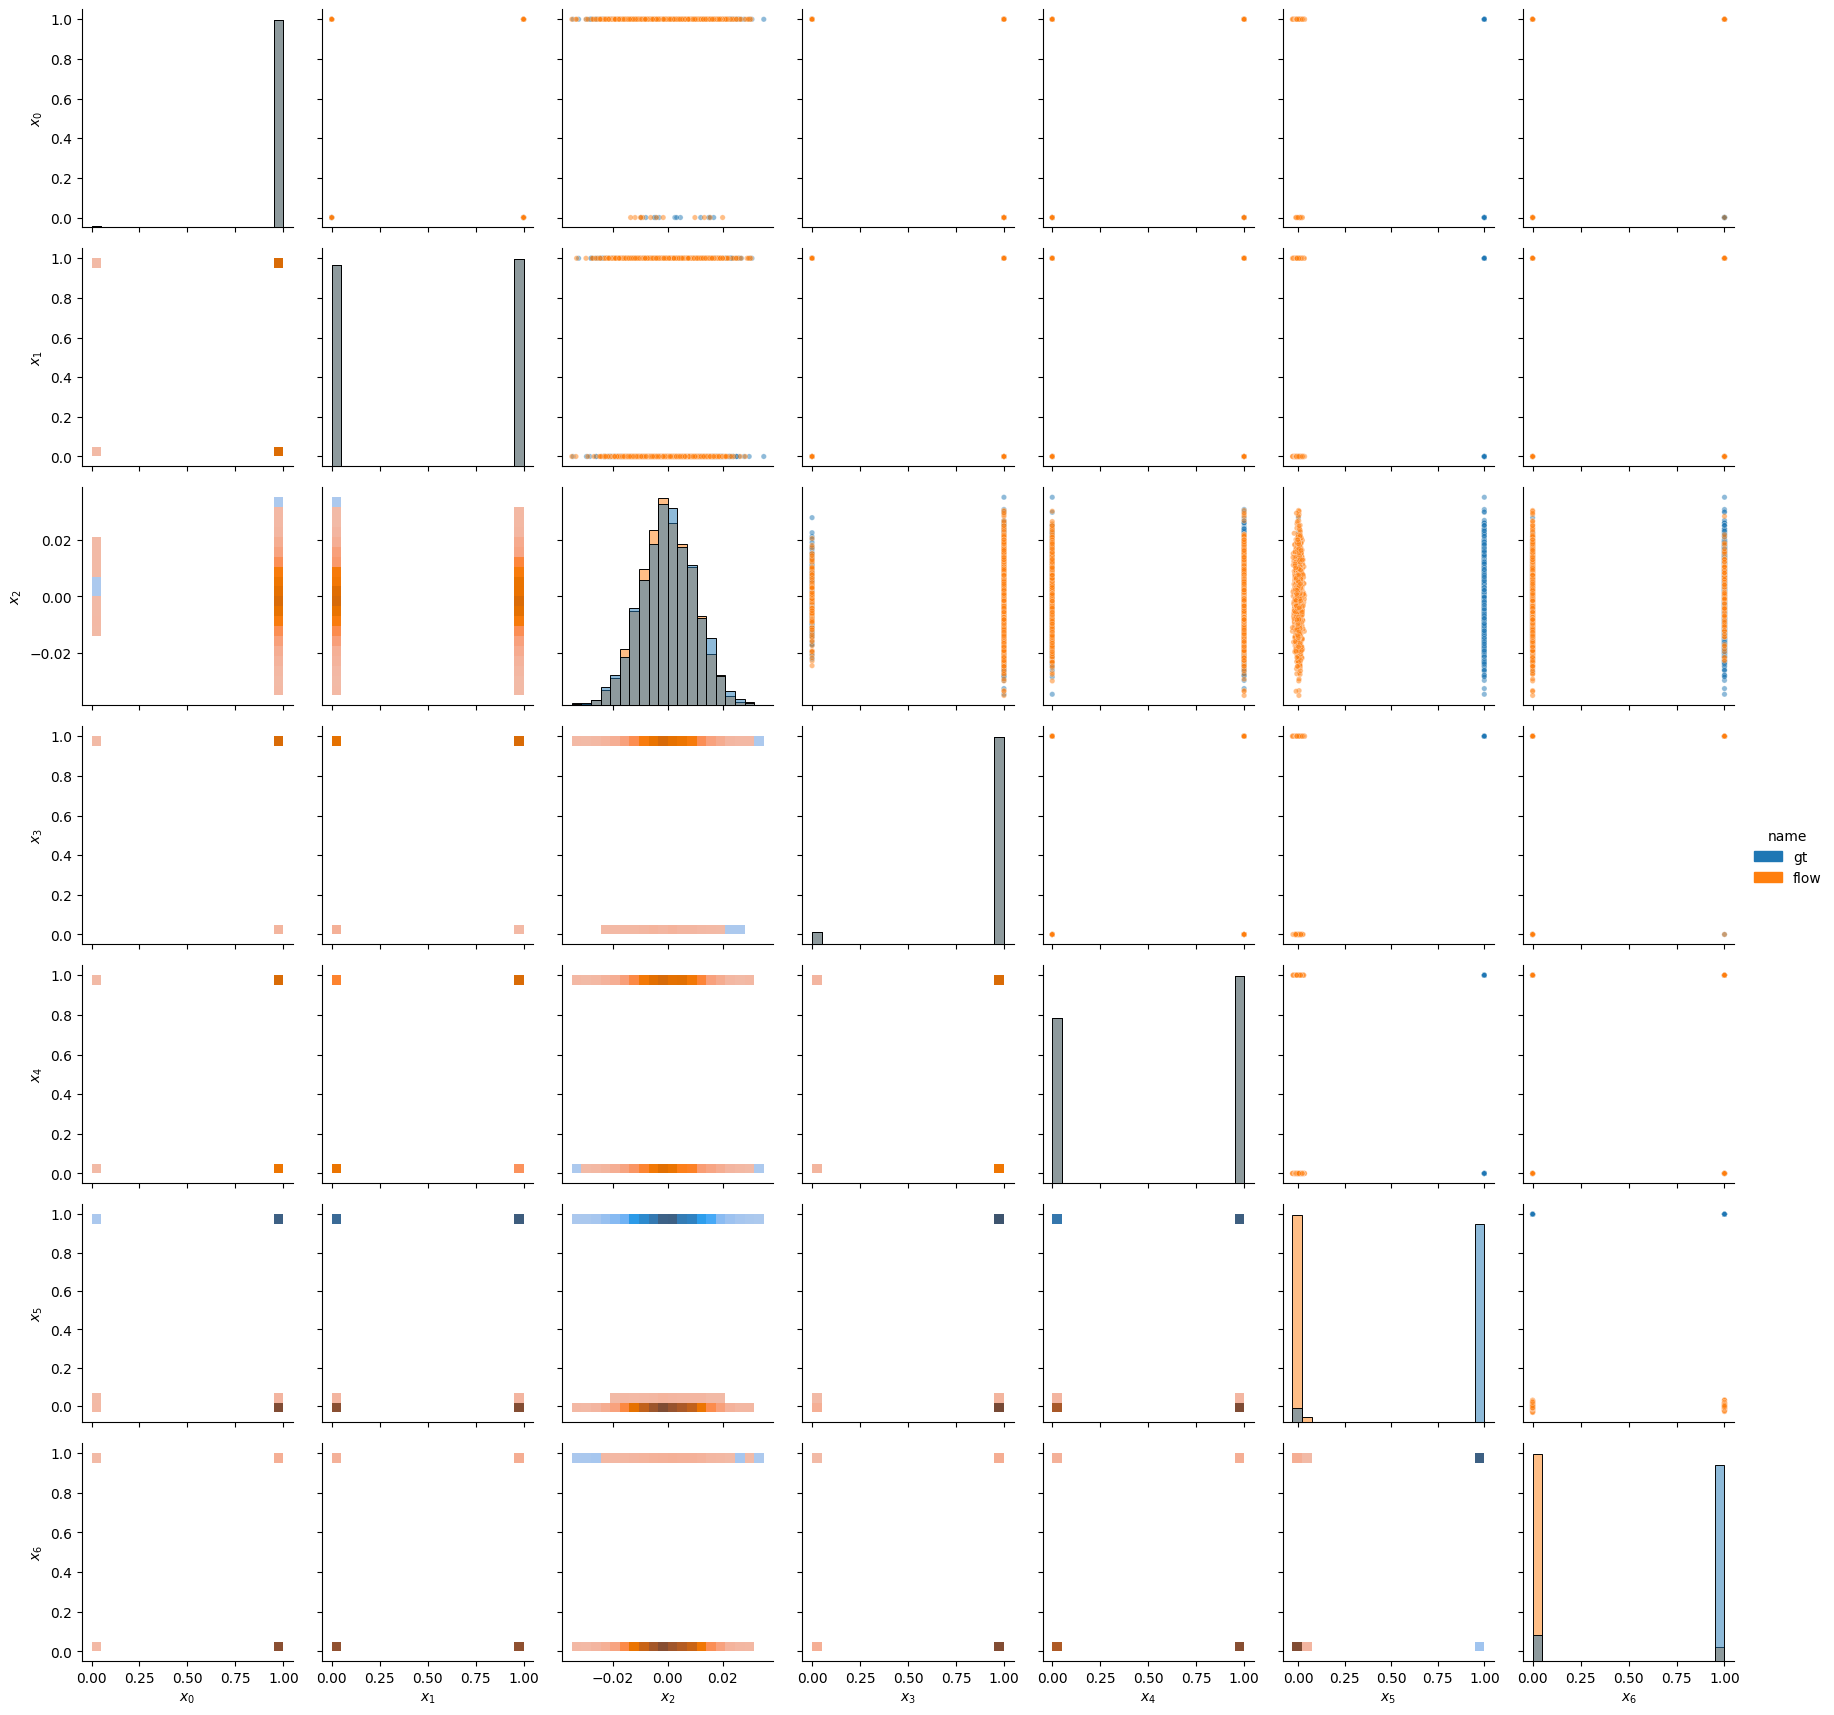

In [20]:
# intervention
index, value = 2, 0
x_cf = test_C_topo_deq.clone()


#"simple" ground truth : fixing value on root node of given factual data
cf_gt = x_cf.clone()
cf_gt[..., index] = value
cf_gt = add_noise(post_process(cf_gt, binary_dims, binary_min_values, binary_max_values))

#generate intervention data
cf_data = flow().compute_counterfactual(x_cf, index=index, value=0+torch.rand(1)).detach().cpu()
cf_data = add_noise(post_process(cf_data, binary_dims, binary_min_values, binary_max_values))

#plot
plot_data({'gt': cf_gt, 'flow': cf_data}, "hist")

## CBM, Causal Analysis.
* First, train vanilla, CBM or C2BM
* Then, extract 'predicted/inferenced' concept labels, corresponding to test dataset samples
* Analyzing distributional gaps between latent representations of true concepts and those derived from predicted concepts. (for 'Leakge analysis')
* Generate counterfactual concept predictions when given factual inputs, and apply them to (Causal)CBM as 'concept interventions' on test time

#### Leakage Analysis

In [73]:
'''
<CBM>
'''
# run_id, incomplete_concepts = "2025-12-07/20-38-14_sachs_complete", None
# run_id, incomplete_concepts = "2025-12-08/13-31-39_sachs_incomplete", ["Mek", "Jnk", "Raf"]
# run_id, incomplete_concepts = "2025-12-07/21-24-11_sachs_incomplete2", ["PIP3", "PIP2", "Plcg"]
# run_id, incomplete_concepts = "2025-12-07/21-39-42_sachs_complete_soft", None
# run_id, incomplete_concepts = "2025-12-08/13-27-41_sachs_incomplete_soft", ["Mek", "Jnk", "Raf"]
# run_id, incomplete_concepts = "2025-12-07/21-41-26_sachs_incomplete2_soft", ["PIP3", "PIP2", "Plcg"]
# run_id, incomplete_concepts = "2025-12-08/18-47-42_sachs_incomplete3", ["Erk", "PKA", "Mek", "PKC", "Raf"]
# run_id, incomplete_concepts = "2025-12-08/18-48-40_sachs_incomplete3_soft", ["Erk", "PKA", "Mek", "PKC", "Raf"]

'''
<CEM>
'''
# run_id, incomplete_concepts = "2025-12-08/13-53-56_cem_sachs_complete", None
# run_id, incomplete_concepts = "2025-12-08/13-56-25_cem_sachs_incomplete", ["PIP3", "PIP2", "Plcg"]
# run_id, incomplete_concepts = "2025-12-08/13-57-24_cem_sachs_complete_soft", None
# run_id, incomplete_concepts = "2025-12-08/13-58-18_cem_sachs_incomplete_soft", ["PIP3", "PIP2", "Plcg"]
# run_id, incomplete_concepts = "2025-12-08/18-49-21_cem_sachs_incomplete3", ["Erk", "PKA", "Mek", "PKC", "Raf"]
run_id, incomplete_concepts = "2025-12-08/18-51-43_cem_sachs_incomplete3_soft", ["Erk", "PKA", "Mek", "PKC", "Raf"]

'''
<C2BM>
'''
# run_id, incomplete_concepts = "2025-12-08/14-10-48_c2bm_sachs_complete", ['Erk', 'PKA', 'Mek', 'PKC', 'Raf']
# run_id, incomplete_concepts = "2025-12-08/14-17-48_c2bm_sachs_complete_soft", ['Erk', 'PKA', 'Mek', 'PKC', 'Raf']


'\n<C2BM>\n'

In [74]:
save_file = "cnf_bundle.pt"
from causalflows.flows import CausalMAF
bundle = torch.load(save_file, map_location="cpu")
flow_loaded = CausalMAF(bundle["features"], bundle["context"], adjacency=bundle["adjacency"])
flow_loaded.load_state_dict(bundle["state_dict"])
flow_loaded.eval()

CausalMAF(
  (transform): MaskedAutoregressiveTransform(
    (base): MonotonicAffineTransform()
    (passes): 5
    (hyper): MaskedMLP(
      (0): MaskedLinear(in_features=10, out_features=64, bias=True)
      (1): ReLU()
      (2): MaskedLinear(in_features=64, out_features=64, bias=True)
      (3): ReLU()
      (4): MaskedLinear(in_features=64, out_features=20, bias=True)
    )
  )
  (base): UnconditionalDistribution(DiagNormal(loc: torch.Size([10]), scale: torch.Size([10])))
)

In [75]:
topo_order_idx = bundle["topo_order_idx"]
original_order = bundle["original_order"]
topological_order = bundle["topological_order"]
binary_dims = bundle["binary_dims"]
binary_min_values = bundle["binary_min_values"]
binary_max_values = bundle["binary_max_values"]
print(original_order)
print(topological_order)

['Erk', 'PKA', 'Mek', 'Jnk', 'PKC', 'Raf', 'P38', 'PIP3', 'PIP2', 'Plcg']
['PKC', 'Plcg', 'PKA', 'PIP3', 'Jnk', 'Raf', 'P38', 'PIP2', 'Mek', 'Erk']


extract ground truth concept labels and align to topological_order : complete concept set

In [76]:

c_file = "/home/younsuk/.cache/c2bm/sachs/preprocessed_dataset_1.pkl"
c = pickle.load(open(c_file, "rb"))
c_tensor = c.data["test"].complete_c

c_tensor_topo = c_tensor[:, topo_order_idx]
c_tensor_topo_deq = c_tensor_topo.clone()
# 고정된 시드로 dequantization하여 재현 가능하게 만듦
torch.manual_seed(42)
c_tensor_topo_deq[:, binary_dims] = c_tensor_topo_deq[:, binary_dims] + torch.rand_like(
    c_tensor_topo_deq[:, binary_dims]
)
y_true = c.data["test"].y.squeeze()

extract predicted concept labels from CBM

In [77]:
import pickle

incomplete_idx = [topological_order.index(name) for name in incomplete_concepts] if incomplete_concepts else None

# predicted concept labels' accuracy
acc_file = f"../outputs/multirun/{run_id}/0/results/c_accuracy.pkl"
acc = pickle.load(open(acc_file, "rb"))
print(acc)

y_acc_file = f"../outputs/multirun/{run_id}/0/results/y_accuracy.pkl"
y_acc = pickle.load(open(y_acc_file, "rb"))["_baseline"]
print(y_acc)

# extracted predicted concept labels
c_hat_file = f"../outputs/multirun/{run_id}/0/results/c_hat_all.pkl"
c_hat = pickle.load(open(c_hat_file, "rb"))

# helper to coerce to 1D float tensor column
def _to_column_tensor(x):
    t = torch.as_tensor(x)
    if t.ndim == 2 and t.shape[1] == 1:
        t = t.squeeze(1)
    return t.float().view(-1, 1)



c_hat_cols = []
for i, name in enumerate(topological_order):
    if name in c_hat:
        print(f"[{name}] add predicted concept")
        c_hat_cols.append(_to_column_tensor(c_hat[name]))
    else:
        print(f"[{name}] add alternative(zero / true) concept")
        # c_hat_cols.append(zero_col_hat)
        c_hat_cols.append(c_tensor_topo[:, i].view(-1, 1))

c_hat_tensor_topo = torch.cat(c_hat_cols, dim=1)
c_hat_tensor_topo_deq = c_hat_tensor_topo.clone()
# 고정된 시드로 dequantization하여 재현 가능하게 만듦
torch.manual_seed(42)
c_hat_tensor_topo_deq[:, binary_dims] = c_hat_tensor_topo_deq[:, binary_dims] + torch.rand_like(
    c_hat_tensor_topo_deq[:, binary_dims]
)
print(c_hat_tensor_topo.shape)



{'Erk': 0.6175000071525574, 'Mek': 0.6144999861717224, 'PKA': 0.7235000133514404, 'PKC': 0.5139999985694885, 'Raf': 0.593999981880188}
0.6259999871253967
[PKC] add predicted concept
[Plcg] add alternative(zero / true) concept
[PKA] add predicted concept
[PIP3] add alternative(zero / true) concept
[Jnk] add alternative(zero / true) concept
[Raf] add predicted concept
[P38] add alternative(zero / true) concept
[PIP2] add alternative(zero / true) concept
[Mek] add predicted concept
[Erk] add predicted concept
torch.Size([2000, 10])


Transform true/predicted concept labels to corresponding latent space

In [78]:
#complete concepts 전용

u_topo = flow_loaded().transform(c_tensor_topo_deq).detach().cpu()
u_hat_topo = flow_loaded().transform(c_hat_tensor_topo_deq).detach().cpu()

if incomplete_concepts:
    u_topo = u_topo[:, incomplete_idx]
    u_hat_topo = u_hat_topo[:, incomplete_idx]


In [79]:
# plot_data({'u_gt': u_topo, 'u_hat': u_hat_topo}, "kde", col_names = incomplete_concepts if incomplete_concepts is not None else topological_order)

Metrics for Leakage Analysis (referece : Leakage and Interpretability in CBM, Parisini, Enrico, et al. 2025)
* CONCEPT-TASK LEAKAGE SCORE
    #  <img src="./CONCEPT_TASK_LEAKAGE_SCORE.png" width="500"/>
* INTERCONCEPT LEAKAGE SCORE
    #  <img src="./INTERCONCEPT_LEAKAGE_SCORE.png" width="500"/>

##### Metrics

In [80]:
# incomplete concepts 전용
if incomplete_concepts:
    scores = compute_ctl_icl(c_hat_tensor_topo[:, incomplete_idx], c_tensor_topo[:, incomplete_idx], y_true, n_neighbors=3)
else:
    scores = compute_ctl_icl(c_hat_tensor_topo, c_tensor_topo, y_true, n_neighbors=3)

mmd = maximum_mean_discrepancy(u_hat_topo, u_topo, kernel_type="rbf", sigma=None)
lld_score = flow_loaded().log_prob(c_tensor_topo_deq).mean() - flow_loaded().log_prob(c_hat_tensor_topo_deq).mean()

acc_list = [a for a in acc.values()]
if any(np.isnan(acc_list)):
    acc_list = [a for a in acc.values() if not np.isnan(a)]


metrics = {
    "y_acc": y_acc,
    "c_acc": sum(acc_list)/len(acc_list),
    "CTL": scores["CTL"],
    "ICL": scores["ICL"],
    "MMD": mmd.item(),
    "LLD": abs(lld_score.item()),
}

for k, v in metrics.items():
    print(f"{k} : {v:.4f}")

y_acc : 0.6260
c_acc : 0.6127
CTL : 0.0061
ICL : 0.2222
MMD : 0.0329
LLD : 0.5293
